# Sommer & Zeger (1991) vitamin A example
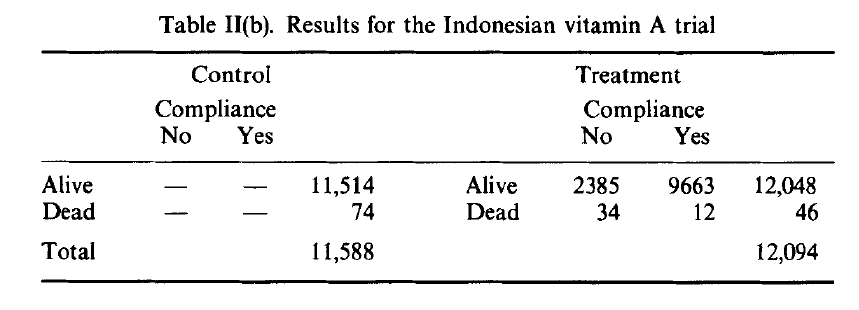

In [ ]:
pip install linearmodels

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# ============================================================
# Sommer & Zeger (1991) vitamin A example
# LATE / CACE on the risk-difference scale
# ============================================================
# Source counts from the paper:
#   control: 11,588 children, 74 deaths
#   treatment-assigned: 12,094 children, 46 deaths
#   among treatment-assigned:
#       complied(received vitamin A): 9,675 children, 12 deaths
#       did not comply:               2,419 children, 34 deaths
#
# Here:
#   Z = random assignment (1=treatment village, 0=control village)
#   W = received vitamin A (1=yes, 0=no)
#   Y = death indicator (1=dead, 0=alive)
#
# This gives one-sided noncompliance: W=0 for all controls.


In [ ]:
# -----------------------------
# 1) Build individual-level data
# -----------------------------
n_control = 11588
deaths_control = 74
alive_control = n_control - deaths_control

n_treat = 12094
n_comply = 9675
n_noncomply = 2419

deaths_comply = 12
alive_comply = n_comply - deaths_comply

deaths_noncomply = 34
alive_noncomply = n_noncomply - deaths_noncomply


# Control arm: Z=0, W=0
Z0 = np.zeros(n_control, dtype=int)
W0 = np.zeros(n_control, dtype=int)
Y0 = np.r_[np.zeros(deaths_control, dtype=int), np.ones(alive_control, dtype=int)]

# Treatment arm, compliers: Z=1, W=1
Z1_c = np.ones(n_comply, dtype=int)
W1_c = np.ones(n_comply, dtype=int)
Y1_c = np.r_[np.zeros(deaths_comply, dtype=int), np.ones(alive_comply, dtype=int)]

# Treatment arm, noncompliers: Z=1, W=0
Z1_n = np.ones(n_noncomply, dtype=int)
W1_n = np.zeros(n_noncomply, dtype=int)
Y1_n = np.r_[np.zeros(deaths_noncomply, dtype=int), np.ones(alive_noncomply, dtype=int)]

Z = np.r_[Z0, Z1_c, Z1_n]
W = np.r_[W0, W1_c, W1_n]
Y = np.r_[Y0, Y1_c, Y1_n]

df = pd.DataFrame({"Z": Z, "W": W, "Y": Y})



## ITT

In [ ]:
# -----------------------------
# 3) ITT estimates + inference
# -----------------------------
def diff_in_means_and_ci(y, z, alpha=0.05):
    """
    Difference in means E[y|Z=1] - E[y|Z=0]
    with usual large-sample standard error for two independent groups.
    """
    y1 = y[z == 1]
    y0 = y[z == 0]

    est = y1.mean() - y0.mean()
    var = y1.var(ddof=1) / len(y1) + y0.var(ddof=1) / len(y0)
    se = np.sqrt(var)
    zcrit = stats.norm.ppf(1 - alpha / 2)
    ci = (est - zcrit * se, est + zcrit * se)
    return est, se, ci


itt_y, se_itt_y, ci_itt_y = diff_in_means_and_ci(df["Y"].to_numpy(), df["Z"].to_numpy())
itt_w, se_itt_w, ci_itt_w = diff_in_means_and_ci(df["W"].to_numpy(), df["Z"].to_numpy())

print("=== ITT estimates ===")
print(f"ITT on mortality E[Y|Z=1]-E[Y|Z=0] = {itt_y:.8f}")
print(f"SE = {se_itt_y:.8f}")
print(f"95% CI = ({ci_itt_y[0]:.8f}, {ci_itt_y[1]:.8f})")
print()




=== ITT estimates ===
ITT on mortality E[Y|Z=1]-E[Y|Z=0] = 0.00258238
SE = 0.00092787
95% CI = (0.00076379, 0.00440096)



## LATE

In [ ]:

def late_from_definition(y, w, z):
    """
    LATE = ITT_Y / ITT_W
    """
    itt_y = y[z == 1].mean() - y[z == 0].mean()
    itt_w = w[z == 1].mean() - w[z == 0].mean()
    return itt_y / itt_w


def late_from_cov_ratio(y, w, z):
    """
    LATE = Cov(Z,Y) / Cov(Z,W)
    """
    zc = z - z.mean()
    cov_zy = np.mean(zc * (y - y.mean()))
    cov_zw = np.mean(zc * (w - w.mean()))
    return cov_zy / cov_zw

from linearmodels.iv import IV2SLS
def tsls(y, w, z):
    """
    2SLS using linearmodels (robust SE).

    Model:
        first stage:  W = pi0 + pi1 Z + v
        second stage: Y = alpha + tau W + u

    Returns tau_hat and robust (HC0) SE.
    """

    # Build DataFrame
    df = pd.DataFrame({
        "Y": np.asarray(y),
        "W": np.asarray(w),
        "Z": np.asarray(z)
    })

    # IV regression: Y ~ 1 + [W ~ Z]
    model = IV2SLS.from_formula("Y ~ 1 + [W ~ Z]", data=df)
    res = model.fit(cov_type="robust")  # HC0 robust SE

    return {
        "alpha_hat": res.params["Intercept"],
        "tau_hat": res.params["W"],
        "se_tau": res.std_errors["W"],
        "vcov": res.cov,
        "res_obj": res   # optional: full result object
    }

# -----------------------------
# 4) LATE/CACE point estimates
# -----------------------------
late_def = late_from_definition(df["Y"].to_numpy(), df["W"].to_numpy(), df["Z"].to_numpy())
late_cov = late_from_cov_ratio(df["Y"].to_numpy(), df["W"].to_numpy(), df["Z"].to_numpy())
tsls_res = tsls(df["Y"].to_numpy(), df["W"].to_numpy(), df["Z"].to_numpy())

print("=== LATE / CACE point estimates (risk-difference scale) ===")
print(f"From definition ITT_Y / ITT_W       = {late_def:.8f}")
print(f"From ratio Cov(Z,Y) / Cov(Z,W)      = {late_cov:.8f}")
print(f"From 2SLS                           = {tsls_res['tau_hat']:.8f}")
print()

# 2SLS analytic robust CI
zcrit = stats.norm.ppf(0.975)
ci_tsls = (
    tsls_res["tau_hat"] - zcrit * tsls_res["se_tau"],
    tsls_res["tau_hat"] + zcrit * tsls_res["se_tau"]
)

print("=== 2SLS robust inference ===")
print(f"Robust SE = {tsls_res['se_tau']:.8f}")
print(f"95% CI    = ({ci_tsls[0]:.8f}, {ci_tsls[1]:.8f})")




=== LATE / CACE point estimates (risk-difference scale) ===
From definition ITT_Y / ITT_W       = 0.00322804
From ratio Cov(Z,Y) / Cov(Z,W)      = 0.00322804
From 2SLS                           = 0.00322804

=== 2SLS robust inference ===
Robust SE = 0.00115916
95% CI    = (0.00095612, 0.00549996)


# Simulation

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# ============================================================
# 1. Data-generating process
# ============================================================
def simulate_noncompliance(n=5000, tau=2.0, seed=123):
    """
    Simulate a randomized experiment with non-compliance.

    Notation
    --------
    Z : randomized assignment (instrument)
    W : treatment actually received
    Y : outcome
    U : unobserved confounder

    Endogeneity
    -----------
    W is endogenous because U affects both:
      (i) whether the unit takes treatment
      (ii) the outcome Y
    """
    rng = np.random.default_rng(seed)

    # Unobserved factor
    U = rng.normal(0, 1, n)

    # Random assignment
    Z = rng.binomial(1, 0.5, n)

    # Noise in treatment take-up decision
    nu = rng.normal(0, 1, n)

    # Actual treatment received (self-selected, hence endogenous)
    # Assignment Z encourages take-up, but U also affects take-up.
    latent_w = -0.4 + 1.2 * Z + 1.0 * U + nu
    W = (latent_w > 0).astype(int)

    # Outcome noise
    eps = rng.normal(0, 1, n)

    # Outcome equation
    Y = 1.0 + tau * W + 1.5 * U + eps

    return pd.DataFrame({"Y": Y, "W": W, "Z": Z, "U": U})



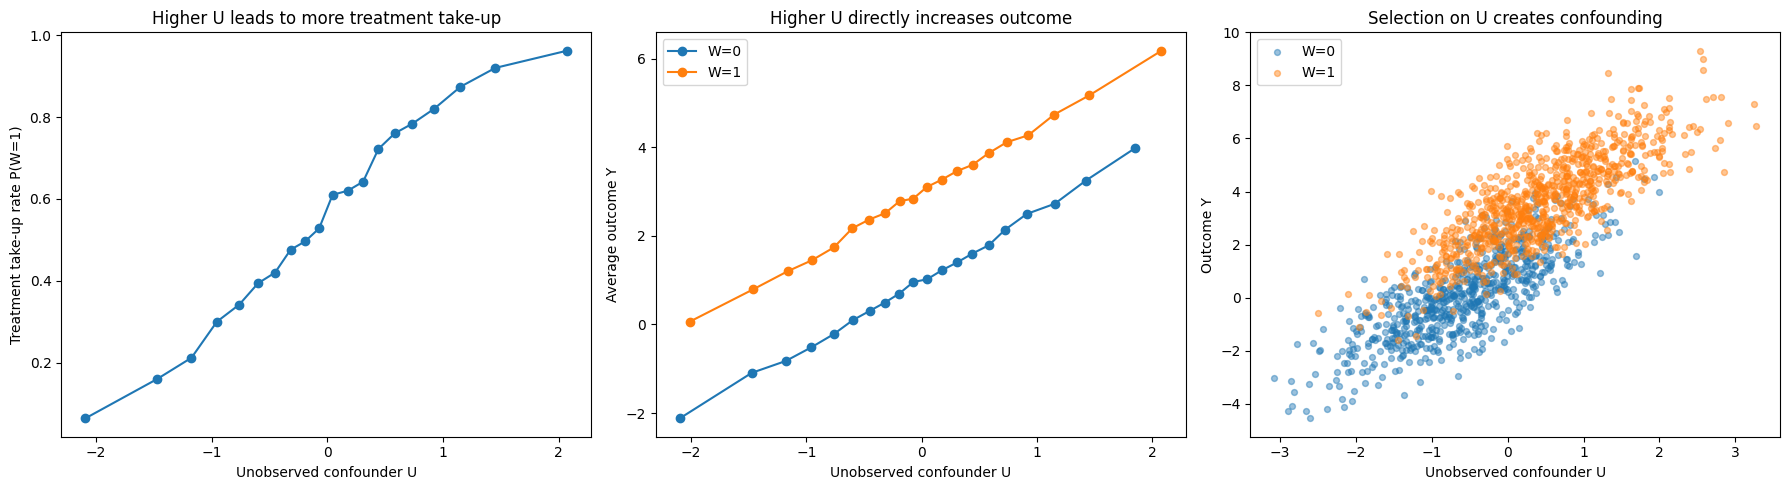

In [ ]:
import matplotlib.pyplot as plt
def plot_confounding_figures(df, nbins=20):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --------------------------------------------------------
    # Plot 1: Treatment rate by U-bin
    # Shows U -> W
    # --------------------------------------------------------
    df1 = df.copy()
    df1["U_bin"] = pd.qcut(df1["U"], q=nbins, duplicates="drop")
    takeup = df1.groupby("U_bin", observed=False).agg(
        U_mid=("U", "mean"),
        W_rate=("W", "mean")
    ).reset_index(drop=True)

    axes[0].plot(takeup["U_mid"], takeup["W_rate"], marker="o")
    axes[0].set_xlabel("Unobserved confounder U")
    axes[0].set_ylabel("Treatment take-up rate P(W=1)")
    axes[0].set_title("Higher U leads to more treatment take-up")

    # --------------------------------------------------------
    # Plot 2: Outcome by U-bin and treatment status
    # Shows U -> Y, within each W group
    # --------------------------------------------------------
    outcome_by_bin = df1.groupby(["U_bin", "W"], observed=False).agg(
        U_mid=("U", "mean"),
        Y_mean=("Y", "mean")
    ).reset_index()

    for w_value, label in [(0, "W=0"), (1, "W=1")]:
        sub = outcome_by_bin[outcome_by_bin["W"] == w_value]
        axes[1].plot(sub["U_mid"], sub["Y_mean"], marker="o", label=label)

    axes[1].set_xlabel("Unobserved confounder U")
    axes[1].set_ylabel("Average outcome Y")
    axes[1].set_title("Higher U directly increases outcome")
    axes[1].legend()

    # --------------------------------------------------------
    # Plot 3: Scatter plot U vs Y, colored by treatment status
    # Shows selection: treated units tend to have higher U and Y
    # --------------------------------------------------------
    sample = df.sample(min(len(df), 1500), random_state=123)

    for w_value, label, alpha in [(0, "W=0", 0.45), (1, "W=1", 0.45)]:
        sub = sample[sample["W"] == w_value]
        axes[2].scatter(sub["U"], sub["Y"], alpha=alpha, label=label, s=18)

    axes[2].set_xlabel("Unobserved confounder U")
    axes[2].set_ylabel("Outcome Y")
    axes[2].set_title("Selection on U creates confounding")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# 3. Run
# ============================================================
df = simulate_noncompliance(n=10000, tau=2.0, seed=42)
plot_confounding_figures(df)

In [ ]:

# ============================================================
# 2. Estimators
# ============================================================
def itt_estimate(df):
    """
    Intention-to-treat (ITT):
        E[Y | Z=1] - E[Y | Z=0]
    Measures the effect of assignment, not necessarily of treatment received.
    """
    return df.loc[df["Z"] == 1, "Y"].mean() - df.loc[df["Z"] == 0, "Y"].mean()


def as_treated_estimate(df):
    """
    As-treated:
        E[Y | W=1] - E[Y | W=0]
    Usually biased because W is endogenous.
    """
    return df.loc[df["W"] == 1, "Y"].mean() - df.loc[df["W"] == 0, "Y"].mean()


def per_protocol_estimate(df):
    """
    Per-protocol:
    Restrict to compliers with protocol:
      - assigned treatment and took treatment: Z=1, W=1
      - assigned control and did not take treatment: Z=0, W=0

    Then compare outcomes within this selected subsample.

    This is generally biased because compliance is not random.
    """
    pp = df[((df["Z"] == 1) & (df["W"] == 1)) | ((df["Z"] == 0) & (df["W"] == 0))].copy()

    est = pp.loc[(pp["Z"] == 1) & (pp["W"] == 1), "Y"].mean() - \
          pp.loc[(pp["Z"] == 0) & (pp["W"] == 0), "Y"].mean()

    return est, len(pp)


def iv_wald_estimate(df):
    """
    IV / Wald estimator:
        [E[Y|Z=1] - E[Y|Z=0]] / [E[W|Z=1] - E[W|Z=0]]

    Uses randomized assignment Z as an instrument for actual treatment W.
    Under standard IV assumptions, identifies LATE.
    """
    num = df.loc[df["Z"] == 1, "Y"].mean() - df.loc[df["Z"] == 0, "Y"].mean()
    den = df.loc[df["Z"] == 1, "W"].mean() - df.loc[df["Z"] == 0, "W"].mean()
    return num / den


# ============================================================
# 3. Regression versions
# ============================================================



def tsls_manual(df):
    """
    Manual 2SLS:
      First stage:  W ~ 1 + Z
      Second stage: Y ~ 1 + W_hat

    This gives the same point estimate as the Wald estimator
    in the just-identified binary-IV case.
    """
    # First stage
    X1 = sm.add_constant(df["Z"])
    first_stage = sm.OLS(df["W"], X1).fit()
    W_hat = first_stage.fittedvalues

    # Second stage
    X2 = sm.add_constant(W_hat)
    second_stage = sm.OLS(df["Y"], X2).fit()

    return first_stage, second_stage


In [ ]:
df = simulate_noncompliance(n=10000, tau=2.0, seed=42)

itt = itt_estimate(df)
at = as_treated_estimate(df)
pp, n_pp = per_protocol_estimate(df)
iv = iv_wald_estimate(df)

print("True causal effect of treatment received (tau): 2.0")
print(f"ITT estimate         : {itt:.4f}")
print(f"As-treated estimate  : {at:.4f}")
print(f"Per-protocol estimate: {pp:.4f}  (selected sample size = {n_pp})")
print(f"IV / Wald estimate   : {iv:.4f}")
print()

print("Take-up rates:")
print(df.groupby("Z")["W"].mean())
print()





True causal effect of treatment received (tau): 2.0
ITT estimate         : 0.6317
As-treated estimate  : 3.5275
Per-protocol estimate: 3.1346  (selected sample size = 6642)
IV / Wald estimate   : 1.9338

Take-up rates:
Z
0    0.389262
1    0.715916
Name: W, dtype: float64



In [ ]:
tsls_res = tsls(df["Y"].to_numpy(), df["W"].to_numpy(), df["Z"].to_numpy())
zcrit = stats.norm.ppf(0.975)
ci_tsls = (
    tsls_res["tau_hat"] - zcrit * tsls_res["se_tau"],
    tsls_res["tau_hat"] + zcrit * tsls_res["se_tau"]
)
print(tsls_res["tau_hat"])
print("=== 2SLS robust inference ===")
print(f"Robust SE = {tsls_res['se_tau']:.8f}")
print(f"95% CI    = ({ci_tsls[0]:.8f}, {ci_tsls[1]:.8f})")

1.9338357318351875
=== 2SLS robust inference ===
Robust SE = 0.11196698
95% CI    = (1.71438448, 2.15328698)


In [ ]:
fs, ss = tsls_manual(df)


print("Second stage: Y on W_hat")
print(ss.summary())

Second stage: Y on W_hat
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     175.3
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           1.12e-39
Time:                        06:51:01   Log-Likelihood:                -22882.
No. Observations:               10000   AIC:                         4.577e+04
Df Residuals:                    9998   BIC:                         4.578e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0149      